## Overview
### Imagine you’ve been hired by FashionX, a fast-growing online fashion retailer struggling to organize its expanding product catalog. The company needs an automated system to classify fashion items into categories like T-shirts, Dresses, Shoes, etc., based on images. As a data scientist, your task is to develop a machine learning model to classify 28x28 pixel images from the Fashion MNIST dataset into 10 fashion categories. You’ll apply algorithms like K-Nearest Neighbors(KNN) and Support Vector Machines (SVM) for classification. Additionally, you’ll use t-SNE to visualize the data, uncovering patterns and clusters in the high-dimensional space. This project will help FashionX scale its operations by efficiently automating product categorization, making it easier for customers to find what they’re looking for.

## Task 1: Data Preprocessing

In [1]:
import tensorflow as tf
from tensorflow.keras.datasets import fashion_mnist
import numpy as np

(train_images, train_labels), (test_images, test_labels) = fashion_mnist.load_data()

train_images = train_images / 255.0
test_images = test_images / 255.0

train_images_flattened = train_images.reshape((-1, 784))
test_images_flattened = test_images.reshape((-1, 784))

X_train, y_train = train_images_flattened[:10000], train_labels[:10000]
X_test, y_test = test_images_flattened[:2000], test_labels[:2000]

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 2us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 10s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 1us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


## Task 2: K-Nearest Neighbors (KNN) Classification

In [2]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

k_values = [3, 5, 7]
for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    y_pred = knn.predict(X_test)
    print(f"KNN Accuracy (k={k}): {accuracy_score(y_test, y_pred):.4f}")

KNN Accuracy (k=3): 0.8195
KNN Accuracy (k=5): 0.8225
KNN Accuracy (k=7): 0.8260


## Task 3: Support Vector Machine (SVM) Classification

In [3]:
from sklearn.svm import SVC


svm_rbf = SVC(kernel='rbf', C=1.0)
svm_rbf.fit(X_train, y_train)
y_pred_svm = svm_rbf.predict(X_test)

print(f"SVM (RBF) Accuracy: {accuracy_score(y_test, y_pred_svm):.4f}")

SVM (RBF) Accuracy: 0.8600


## Task 4: Data Visualization with t-SNE

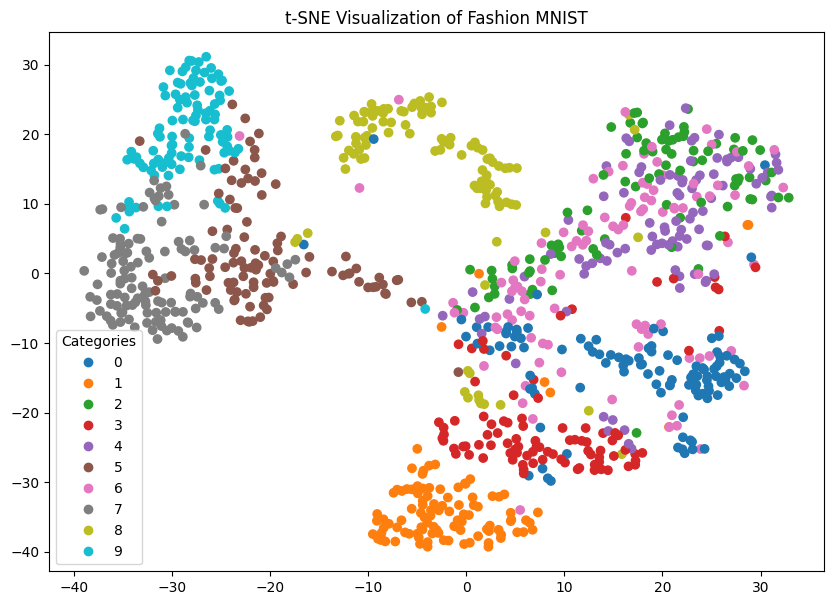

In [4]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

tsne = TSNE(n_components=2, random_state=42)
X_tsne = tsne.fit_transform(X_train[:1000])

plt.figure(figsize=(10, 7))
scatter = plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=y_train[:1000], cmap='tab10')
plt.legend(*scatter.legend_elements(), title="Categories")
plt.title("t-SNE Visualization of Fashion MNIST")
plt.show()

## Task 5: Model Evaluation and Reporting

In [5]:
from sklearn.metrics import classification_report, confusion_matrix

print("Final SVM Evaluation:")
print(classification_report(y_test, y_pred_svm))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_svm))

Final SVM Evaluation:
              precision    recall  f1-score   support

           0       0.85      0.80      0.82       200
           1       0.97      0.95      0.96       203
           2       0.77      0.80      0.79       214
           3       0.80      0.88      0.84       190
           4       0.80      0.77      0.79       219
           5       0.93      0.92      0.93       195
           6       0.66      0.66      0.66       197
           7       0.90      0.94      0.92       200
           8       0.98      0.95      0.97       194
           9       0.97      0.93      0.95       188

    accuracy                           0.86      2000
   macro avg       0.86      0.86      0.86      2000
weighted avg       0.86      0.86      0.86      2000

Confusion Matrix:
[[159   1   2  14   1   0  23   0   0   0]
 [  0 192   0  11   0   0   0   0   0   0]
 [  2   0 172   2  22   0  16   0   0   0]
 [  5   3   1 168   5   0   7   0   1   0]
 [  0   0  25   6 169   0  18